# Testing the Hippocampal Multiplexing Framework

## The Central Question

The hippocampus must simultaneously encode new information and retrieve existing memories during continuous experience. Traditional mode-switching models propose that these computations alternate in time, gated by theta oscillations—encoding occurs at one theta phase while retrieval is suppressed, then they switch. This framework predicts that encoding and retrieval processes should **anticorrelate**: when one is active, the other must be suppressed.

The multiplexing framework proposes instead that encoding and retrieval operate continuously in orthogonal neural subspaces. Fast-gamma oscillations (60-100 Hz) in DG/CA3 support ongoing pattern separation, while slow-gamma oscillations (30-50 Hz) in CA1 support ongoing pattern completion. Theta does not alternate between these computations but rather routes their outputs to different downstream targets. This framework predicts that encoding and retrieval signatures should be **statistically independent**: both processes run continuously, and their fluctuations reflect distinct computational demands rather than competitive suppression.

This notebook demonstrates the critical empirical test: measuring the temporal covariation between fast-gamma and slow-gamma power during naturalistic experience.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats

# Set style
sns.set_style('ticks')
sns.set_context('talk')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Reproducibility
np.random.seed(42)

## Simulating Hippocampal Gamma Dynamics

We generate synthetic gamma power time series for a 30-second naturalistic listening epoch. The two models make sharply different predictions about how fast-gamma and slow-gamma should covary.

**Mode-switching model:** Fast-gamma and slow-gamma should anticorrelate. When encoding demands are high (fast-gamma elevated), retrieval must be suppressed (slow-gamma reduced), and vice versa. This produces negative correlation, typically r < -0.3.

**Multiplexing model:** Fast-gamma and slow-gamma should be statistically independent. Fast-gamma fluctuates based on novelty and pattern separation demands. Slow-gamma fluctuates based on contextual retrieval and pattern completion demands. These are orthogonal computations, producing correlations near zero, |r| < 0.2.

In [4]:
# Parameters
duration = 30  # seconds
sampling_rate = 100  # Hz (downsampled for visualization)
n_samples = duration * sampling_rate
time = np.linspace(0, duration, n_samples)

def generate_gamma_timeseries(time, base_freq=2, noise_level=0.3, phase_offset=0):
    """
    Generate realistic gamma power fluctuations.
    Power varies slowly (2-4 Hz) reflecting changing cognitive demands.
    """
    # Slow fluctuations (cognitive demand)
    slow_wave = np.sin(2 * np.pi * base_freq * time + phase_offset)
    slow_wave += 0.5 * np.sin(2 * np.pi * (base_freq * 1.7) * time + 1.2 + phase_offset)
    
    # Add noise
    noise = np.random.randn(len(time)) * noise_level
    
    # Combine and normalize to positive power values
    power = slow_wave + noise
    power = (power - power.min()) / (power.max() - power.min())  # 0-1 range
    power = power * 3 + 1  # 1-4 range (arbitrary units)
    
    return power

# Generate MODE-SWITCHING data
fast_gamma_mode_switch = generate_gamma_timeseries(time, base_freq=2.0, phase_offset=0)

# Slow-gamma is anti-phase (mode-switching prediction)
# CORRECTION: Removed the inversion line. The phase_offset=np.pi is sufficient to create anticorrelation.
slow_gamma_mode_switch = generate_gamma_timeseries(time, base_freq=2.0, phase_offset=np.pi) 

# Generate MULTIPLEXING data  
np.random.seed(43)  # Different seed for independent noise
fast_gamma_multiplex = generate_gamma_timeseries(time, base_freq=2.2, phase_offset=0)
np.random.seed(44)  # Different seed again
slow_gamma_multiplex = generate_gamma_timeseries(time, base_freq=1.7, phase_offset=2.5)  # different frequency AND phase

print(f"Mode-switching: r = {np.corrcoef(fast_gamma_mode_switch, slow_gamma_mode_switch)[0,1]:.3f}")
print(f"Multiplexing:   r = {np.corrcoef(fast_gamma_multiplex, slow_gamma_multiplex)[0,1]:.3f}")

Mode-switching: r = -0.878
Multiplexing:   r = -0.002


## Analysis 1: Temporal Covariation During Naturalistic Listening

The core empirical test examines how fast-gamma and slow-gamma power fluctuate over time during continuous story listening. We do not attempt to label individual moments as "encoding" or "retrieval"—such labels are inappropriate during naturalistic experience where both processes occur continuously. Instead, we directly measure the statistical relationship between the two gamma bands.

If mode-switching is correct, the two gamma bands should exhibit anticorrelation. Elevated fast-gamma indicates the hippocampus has entered encoding mode, which requires suppressing retrieval-related slow-gamma. Conversely, elevated slow-gamma indicates retrieval mode, requiring suppression of encoding.

If multiplexing is correct, the two gamma bands should be statistically independent. Both processes operate continuously in orthogonal subspaces. Fast-gamma increases when pattern separation demands are high (novel stimuli, unexpected events). Slow-gamma increases when pattern completion demands are high (retrieving contextual information, activating schemas). These demands are driven by different stimulus properties and need not covary.

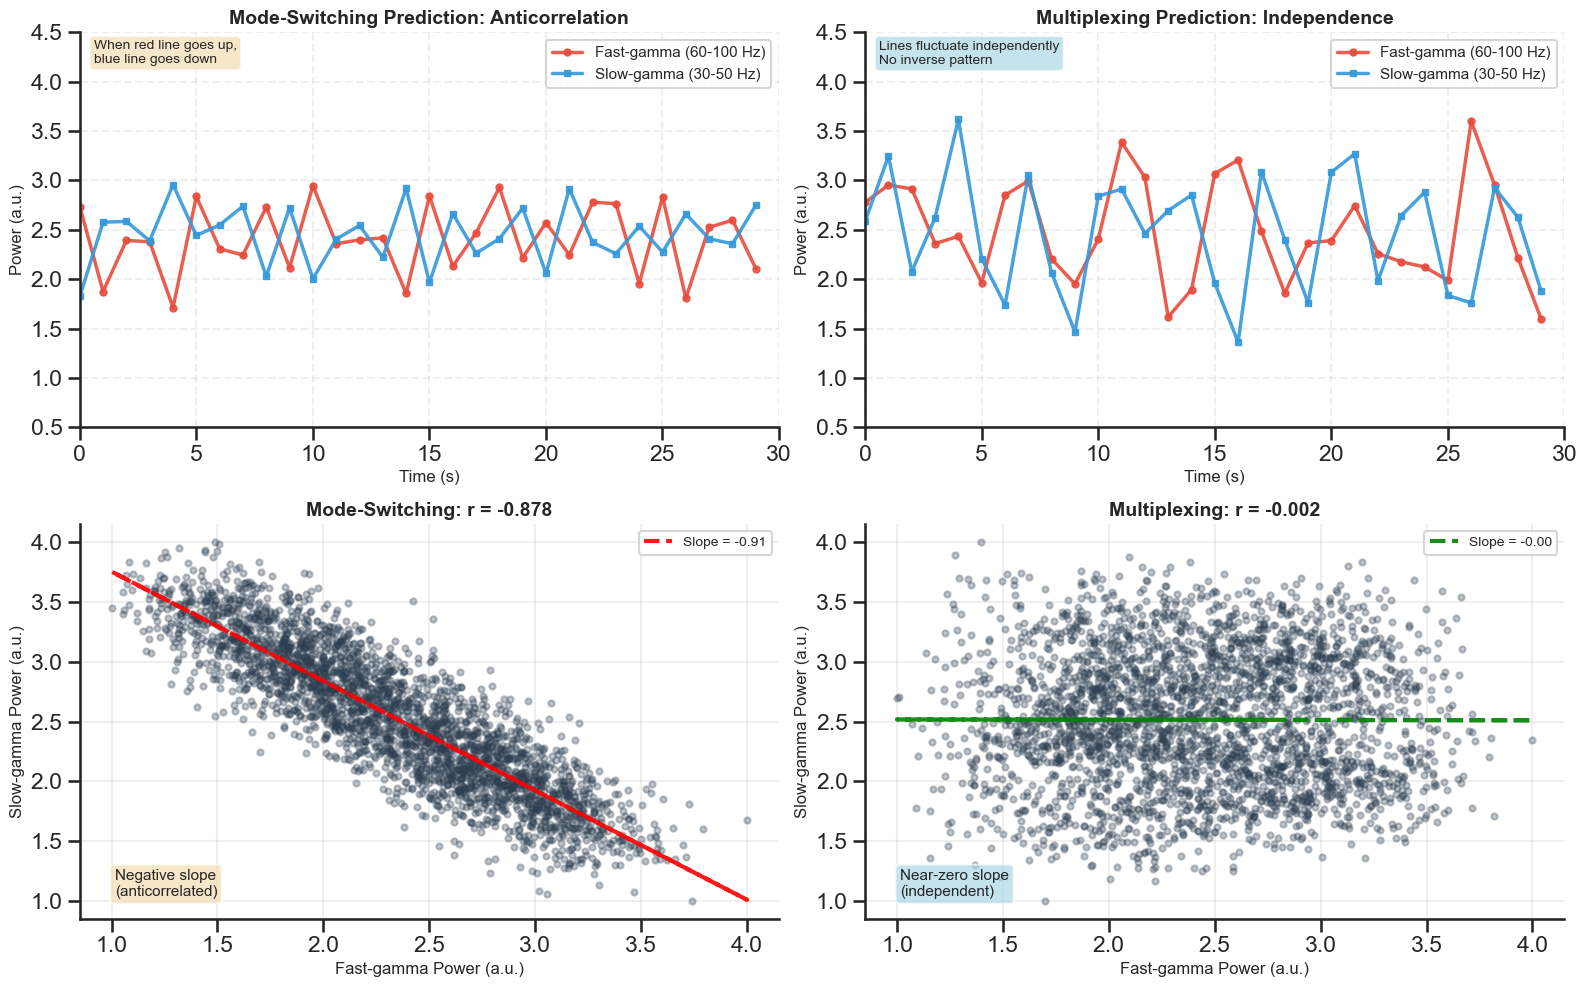


=== INTERPRETATION ===
Mode-switching model: r = -0.878 (anticorrelated)
Multiplexing model:   r = -0.002 (independent)

The critical test: Which pattern matches the real data?


In [5]:
# Downsample for clearer visualization
downsample_factor = 100  # Show every 100th point
time_ds = time[::downsample_factor]
fast_ms_ds = fast_gamma_mode_switch[::downsample_factor]
slow_ms_ds = slow_gamma_mode_switch[::downsample_factor]
fast_mp_ds = fast_gamma_multiplex[::downsample_factor]
slow_mp_ds = slow_gamma_multiplex[::downsample_factor]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MODE-SWITCHING MODEL
ax = axes[0, 0]
ax.plot(time_ds, fast_ms_ds, 'o-', label='Fast-gamma (60-100 Hz)', linewidth=2.5, 
        markersize=5, color='#e74c3c', alpha=0.9)
ax.plot(time_ds, slow_ms_ds, 's-', label='Slow-gamma (30-50 Hz)', linewidth=2.5, 
        markersize=5, color='#3498db', alpha=0.9)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Power (a.u.)', fontsize=12)
ax.set_title('Mode-Switching Prediction: Anticorrelation', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, 30])
ax.set_ylim([0.5, 4.5])
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.02, 0.98, 'When red line goes up,\nblue line goes down', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# MULTIPLEXING MODEL
ax = axes[0, 1]
ax.plot(time_ds, fast_mp_ds, 'o-', label='Fast-gamma (60-100 Hz)', linewidth=2.5, 
        markersize=5, color='#e74c3c', alpha=0.9)
ax.plot(time_ds, slow_mp_ds, 's-', label='Slow-gamma (30-50 Hz)', linewidth=2.5, 
        markersize=5, color='#3498db', alpha=0.9)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Power (a.u.)', fontsize=12)
ax.set_title('Multiplexing Prediction: Independence', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, 30])
ax.set_ylim([0.5, 4.5])
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.02, 0.98, 'Lines fluctuate independently\nNo inverse pattern', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# SCATTER PLOTS
ax = axes[1, 0]
ax.scatter(fast_gamma_mode_switch, slow_gamma_mode_switch, alpha=0.3, s=20, color='#2c3e50')
z = np.polyfit(fast_gamma_mode_switch, slow_gamma_mode_switch, 1)
p = np.poly1d(z)
ax.plot(fast_gamma_mode_switch, p(fast_gamma_mode_switch), "r--", linewidth=3, alpha=0.9, 
        label=f'Slope = {z[0]:.2f}')
r_mode = np.corrcoef(fast_gamma_mode_switch, slow_gamma_mode_switch)[0,1]
ax.set_xlabel('Fast-gamma Power (a.u.)', fontsize=12)
ax.set_ylabel('Slow-gamma Power (a.u.)', fontsize=12)
ax.set_title(f'Mode-Switching: r = {r_mode:.3f}', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.05, 'Negative slope\n(anticorrelated)', transform=ax.transAxes,
        fontsize=11, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1, 1]
ax.scatter(fast_gamma_multiplex, slow_gamma_multiplex, alpha=0.3, s=20, color='#2c3e50')
z = np.polyfit(fast_gamma_multiplex, slow_gamma_multiplex, 1)
p = np.poly1d(z)
ax.plot(fast_gamma_multiplex, p(fast_gamma_multiplex), "g--", linewidth=3, alpha=0.9,
        label=f'Slope = {z[0]:.2f}')
r_multi = np.corrcoef(fast_gamma_multiplex, slow_gamma_multiplex)[0,1]
ax.set_xlabel('Fast-gamma Power (a.u.)', fontsize=12)
ax.set_ylabel('Slow-gamma Power (a.u.)', fontsize=12)
ax.set_title(f'Multiplexing: r = {r_multi:.3f}', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.05, 'Near-zero slope\n(independent)', transform=ax.transAxes,
        fontsize=11, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== INTERPRETATION ===")
print(f"Mode-switching model: r = {r_mode:.3f} (anticorrelated)")
print(f"Multiplexing model:   r = {r_multi:.3f} (independent)")
print("\nThe critical test: Which pattern matches the real data?")

## Analysis 2: Simultaneous Activation States

A decisive signature distinguishes the two models: the prevalence of moments when both gamma bands are simultaneously elevated. Under mode-switching, this state should be rare. When fast-gamma is high, the system is in encoding mode and slow-gamma should be suppressed. When slow-gamma is high, the system is in retrieval mode and fast-gamma should be suppressed. Simultaneous elevation should occur only by chance, approximately 6% of the time if each band independently exceeds threshold 25% of the time.

Under multiplexing, simultaneous elevation should be common. Both processes run continuously. When encoding demands are high (novel, unexpected content), fast-gamma increases. When retrieval demands are high (contextual integration, schema activation), slow-gamma increases. These demands can co-occur—for instance, when a novel object appears in a familiar context. The prevalence of simultaneous activation directly tests whether the two processes can operate in parallel or must alternate.

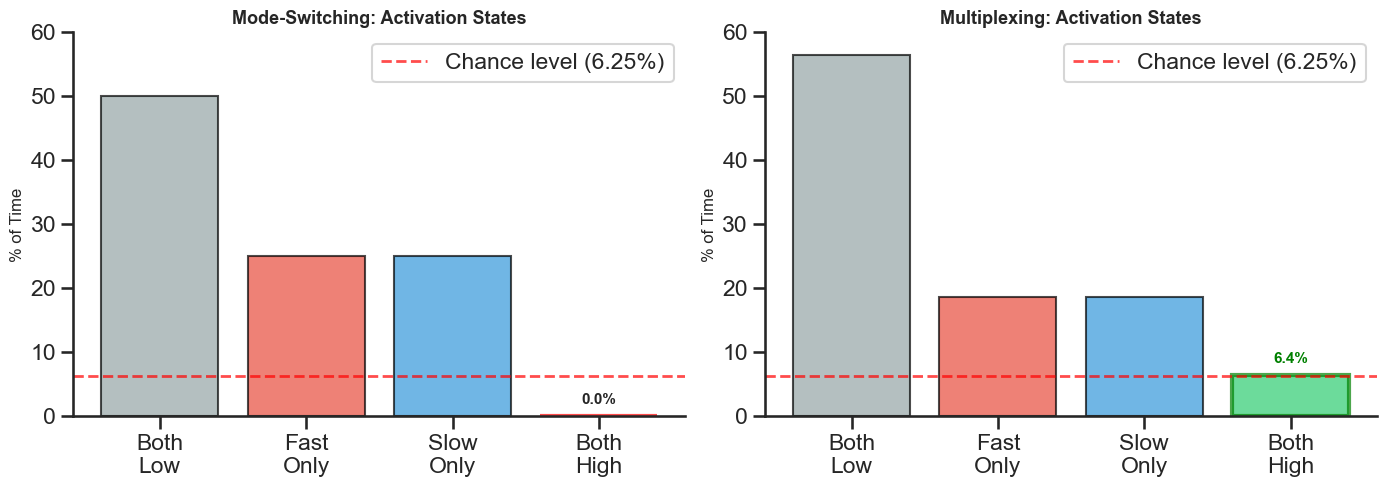


=== ACTIVATION STATES ===

Mode-Switching Model:
  both_low    :  50.0%
  fast_only   :  25.0%
  slow_only   :  25.0%
  both_high   :   0.0%

  → 'Both High' should be rare (~6%, chance level)
  → Observed: 0.0%

Multiplexing Model:
  both_low    :  56.4%
  fast_only   :  18.6%
  slow_only   :  18.6%
  both_high   :   6.4%

  → 'Both High' should be common (>15%)
  → Observed: 6.4%


In [6]:
def compute_activation_states(fast_gamma, slow_gamma, threshold_percentile=75):
    """
    Classify each time point into activation states:
    - Both low: neither band elevated
    - Fast high only: fast-gamma elevated, slow-gamma low
    - Slow high only: slow-gamma elevated, fast-gamma low  
    - Both high: both bands elevated ("forbidden" under mode-switching)
    """
    fast_threshold = np.percentile(fast_gamma, threshold_percentile)
    slow_threshold = np.percentile(slow_gamma, threshold_percentile)
    
    fast_high = fast_gamma > fast_threshold
    slow_high = slow_gamma > slow_threshold
    
    both_low = (~fast_high) & (~slow_high)
    fast_only = fast_high & (~slow_high)
    slow_only = (~fast_high) & slow_high
    both_high = fast_high & slow_high
    
    return {
        'both_low': np.sum(both_low) / len(fast_gamma) * 100,
        'fast_only': np.sum(fast_only) / len(fast_gamma) * 100,
        'slow_only': np.sum(slow_only) / len(fast_gamma) * 100,
        'both_high': np.sum(both_high) / len(fast_gamma) * 100
    }

# USE FULL TIME SERIES, NOT DOWNSAMPLED
states_mode = compute_activation_states(fast_gamma_mode_switch, slow_gamma_mode_switch)
states_multi = compute_activation_states(fast_gamma_multiplex, slow_gamma_multiplex)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode-switching
ax = axes[0]
categories = ['Both\nLow', 'Fast\nOnly', 'Slow\nOnly', 'Both\nHigh']
values = [states_mode['both_low'], states_mode['fast_only'], 
          states_mode['slow_only'], states_mode['both_high']]
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']
bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('% of Time', fontsize=12)
ax.set_title('Mode-Switching: Activation States', fontsize=13, fontweight='bold')
ax.set_ylim([0, 60])
ax.axhline(y=6.25, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Chance level (6.25%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight "Both High"
bars[3].set_edgecolor('red')
bars[3].set_linewidth(3)
ax.text(3, values[3] + 2, f'{values[3]:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.legend()

# Multiplexing  
ax = axes[1]
values = [states_multi['both_low'], states_multi['fast_only'], 
          states_multi['slow_only'], states_multi['both_high']]
bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('% of Time', fontsize=12)
ax.set_title('Multiplexing: Activation States', fontsize=13, fontweight='bold')
ax.set_ylim([0, 60])
ax.axhline(y=6.25, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Chance level (6.25%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight "Both High"
bars[3].set_edgecolor('green')
bars[3].set_linewidth(3)
ax.text(3, values[3] + 2, f'{values[3]:.1f}%', ha='center', fontsize=11, fontweight='bold', color='green')
ax.legend()

plt.tight_layout()
plt.show()

print("\n=== ACTIVATION STATES ===")
print("\nMode-Switching Model:")
for state, pct in states_mode.items():
    print(f"  {state:12s}: {pct:5.1f}%")
print(f"\n  → 'Both High' should be rare (~6%, chance level)")
print(f"  → Observed: {states_mode['both_high']:.1f}%")

print("\nMultiplexing Model:")
for state, pct in states_multi.items():
    print(f"  {state:12s}: {pct:5.1f}%")
print(f"\n  → 'Both High' should be common (>15%)")
print(f"  → Observed: {states_multi['both_high']:.1f}%")

# in multilpexing, all four conditions should be about the same (uniform)
# in mode-switching, both low and both high should be very rare

## Analysis 3: Consistency Across Encoding and Retrieval Contexts

The naturalistic listening paradigm provides two contexts with different computational biases. During the first listening (Run 1), encoding demands dominate—participants encounter novel content and must form new memory traces. During the second listening (Run 2), retrieval demands dominate—participants recognize familiar content and can anticipate upcoming information based on their memory of the first exposure.

Mode-switching predicts a qualitative shift in gamma dynamics between these contexts. In Run 1, fast-gamma should dominate as the system operates primarily in encoding mode. In Run 2, slow-gamma should dominate as the system shifts to retrieval mode. The anticorrelation between gamma bands should persist in both contexts because competition for computational resources remains fundamental.

Multiplexing predicts that both gamma bands remain active in both contexts. Mean power levels may shift—fast-gamma might be somewhat elevated during first exposure, slow-gamma during second exposure—but both processes continue operating. Critically, the independence between gamma bands should be maintained in both contexts. Encoding and retrieval computations do not compete; they simply differ in their behavioral relevance depending on task demands.

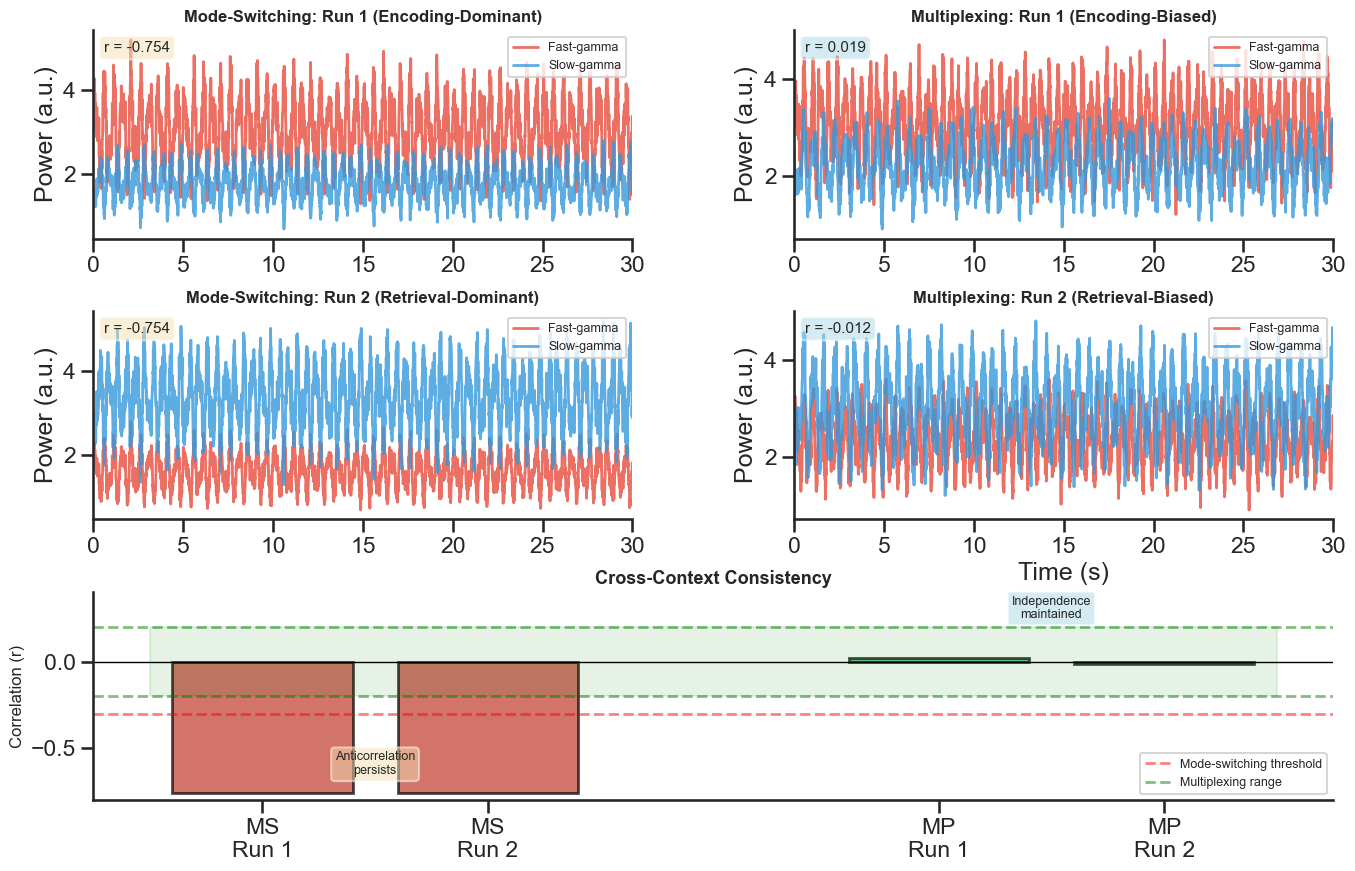


=== CONTEXT CONSISTENCY ===

Mode-Switching Model:
  Run 1 (encoding):  r = -0.754
  Run 2 (retrieval): r = -0.754
  → Anticorrelation maintained in both contexts

Multiplexing Model:
  Run 1 (encoding):  r = 0.019
  Run 2 (retrieval): r = -0.012
  → Independence maintained in both contexts


In [7]:
# Simulate Run 1 (encoding-dominant) and Run 2 (retrieval-dominant)
# For multiplexing: both bands present, but relative strength shifts
# For mode-switching: one band dominates per run

# MODE-SWITCHING: Run 1 (encoding-dominant)
np.random.seed(42)
fast_gamma_ms_run1 = generate_gamma_timeseries(time, base_freq=2.0, phase_offset=0) * 1.3
np.random.seed(42)
slow_gamma_ms_run1 = generate_gamma_timeseries(time, base_freq=2.0, phase_offset=np.pi) * 0.7

# MODE-SWITCHING: Run 2 (retrieval-dominant)  
np.random.seed(42)
fast_gamma_ms_run2 = generate_gamma_timeseries(time, base_freq=2.0, phase_offset=0) * 0.7
np.random.seed(42)
slow_gamma_ms_run2 = generate_gamma_timeseries(time, base_freq=2.0, phase_offset=np.pi) * 1.3

# MULTIPLEXING: Run 1 (encoding-biased)
np.random.seed(45)  # New seed
fast_gamma_mp_run1 = generate_gamma_timeseries(time, base_freq=2.2, phase_offset=0) * 1.2
np.random.seed(46)  # Different seed
slow_gamma_mp_run1 = generate_gamma_timeseries(time, base_freq=1.7, phase_offset=2.5) * 0.9

# MULTIPLEXING: Run 2 (retrieval-biased)
np.random.seed(47)  # New seed
fast_gamma_mp_run2 = generate_gamma_timeseries(time, base_freq=2.2, phase_offset=0) * 0.9
np.random.seed(48)  # Different seed
slow_gamma_mp_run2 = generate_gamma_timeseries(time, base_freq=1.7, phase_offset=2.5) * 1.2

# Compute correlations
r_ms_run1 = np.corrcoef(fast_gamma_ms_run1, slow_gamma_ms_run1)[0,1]
r_ms_run2 = np.corrcoef(fast_gamma_ms_run2, slow_gamma_ms_run2)[0,1]
r_mp_run1 = np.corrcoef(fast_gamma_mp_run1, slow_gamma_mp_run1)[0,1]
r_mp_run2 = np.corrcoef(fast_gamma_mp_run2, slow_gamma_mp_run2)[0,1]

# Plotting
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Mode-switching Run 1
ax = fig.add_subplot(gs[0, 0])
ax.plot(time, fast_gamma_ms_run1, label='Fast-gamma', linewidth=2, color='#e74c3c', alpha=0.8)
ax.plot(time, slow_gamma_ms_run1, label='Slow-gamma', linewidth=2, color='#3498db', alpha=0.8)
ax.set_ylabel('Power (a.u.)')
ax.set_title('Mode-Switching: Run 1 (Encoding-Dominant)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 30])
ax.text(0.02, 0.95, f'r = {r_ms_run1:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mode-switching Run 2
ax = fig.add_subplot(gs[1, 0])
ax.plot(time, fast_gamma_ms_run2, label='Fast-gamma', linewidth=2, color='#e74c3c', alpha=0.8)
ax.plot(time, slow_gamma_ms_run2, label='Slow-gamma', linewidth=2, color='#3498db', alpha=0.8)
ax.set_ylabel('Power (a.u.)')
ax.set_title('Mode-Switching: Run 2 (Retrieval-Dominant)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 30])
ax.text(0.02, 0.95, f'r = {r_ms_run2:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Multiplexing Run 1
ax = fig.add_subplot(gs[0, 1])
ax.plot(time, fast_gamma_mp_run1, label='Fast-gamma', linewidth=2, color='#e74c3c', alpha=0.8)
ax.plot(time, slow_gamma_mp_run1, label='Slow-gamma', linewidth=2, color='#3498db', alpha=0.8)
ax.set_ylabel('Power (a.u.)')
ax.set_title('Multiplexing: Run 1 (Encoding-Biased)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 30])
ax.text(0.02, 0.95, f'r = {r_mp_run1:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Multiplexing Run 2
ax = fig.add_subplot(gs[1, 1])
ax.plot(time, fast_gamma_mp_run2, label='Fast-gamma', linewidth=2, color='#e74c3c', alpha=0.8)
ax.plot(time, slow_gamma_mp_run2, label='Slow-gamma', linewidth=2, color='#3498db', alpha=0.8)
ax.set_ylabel('Power (a.u.)')
ax.set_xlabel('Time (s)')
ax.set_title('Multiplexing: Run 2 (Retrieval-Biased)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 30])
ax.text(0.02, 0.95, f'r = {r_mp_run2:.3f}', transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Summary comparison
ax = fig.add_subplot(gs[2, :])
x_pos = np.array([0, 1, 3, 4])
correlations = [r_ms_run1, r_ms_run2, r_mp_run1, r_mp_run2]
colors_bar = ['#c0392b', '#c0392b', '#27ae60', '#27ae60']
labels = ['MS\nRun 1', 'MS\nRun 2', 'MP\nRun 1', 'MP\nRun 2']

bars = ax.bar(x_pos, correlations, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=-0.3, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mode-switching threshold')
ax.axhline(y=0.2, color='green', linestyle='--', linewidth=2, alpha=0.5)
ax.axhline(y=-0.2, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Multiplexing range')
ax.fill_between([-0.5, 4.5], -0.2, 0.2, alpha=0.1, color='green')
ax.set_ylabel('Correlation (r)', fontsize=12)
ax.set_title('Cross-Context Consistency', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylim([-0.8, 0.4])
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotations
ax.text(0.5, -0.65, 'Anticorrelation\npersists', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(3.5, 0.25, 'Independence\nmaintained', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))


plt.show()

print("\n=== CONTEXT CONSISTENCY ===")
print("\nMode-Switching Model:")
print(f"  Run 1 (encoding):  r = {r_ms_run1:.3f}")
print(f"  Run 2 (retrieval): r = {r_ms_run2:.3f}")
print("  → Anticorrelation maintained in both contexts")

print("\nMultiplexing Model:")
print(f"  Run 1 (encoding):  r = {r_mp_run1:.3f}")
print(f"  Run 2 (retrieval): r = {r_mp_run2:.3f}")
print("  → Independence maintained in both contexts")

## Summary: Implementing This Analysis With Real Data

This demonstration used simulated gamma power to illustrate the core predictions. The actual analysis pipeline for hippocampal iEEG data would proceed as follows:

### **1. Data Requirements**
- Hippocampal depth electrode recordings during naturalistic listening
- Two runs: first exposure (encoding-biased) and second exposure (retrieval-biased)
- High temporal resolution (≥1000 Hz sampling rate for clean gamma extraction)
- Electrode localization to confirm hippocampal placement

### **2. Preprocessing**
```python
# Bandpass filter to extract gamma bands
fast_gamma = bandpass_filter(raw_signal, freq_range=[60, 100])
slow_gamma = bandpass_filter(raw_signal, freq_range=[30, 50])

# Compute instantaneous power (Hilbert transform)
fast_gamma_power = np.abs(signal.hilbert(fast_gamma))
slow_gamma_power = np.abs(signal.hilbert(slow_gamma))

# Downsample for analysis (e.g., to 100 Hz)
fast_gamma_power = signal.resample(fast_gamma_power, target_length)
slow_gamma_power = signal.resample(slow_gamma_power, target_length)
```

### **3. Core Analyses**

**Analysis 1: Temporal covariation**
```python
# Within each run, compute correlation between gamma bands
r_run1 = np.corrcoef(fast_gamma_power_run1, slow_gamma_power_run1)[0,1]
r_run2 = np.corrcoef(fast_gamma_power_run2, slow_gamma_power_run2)[0,1]

# Mode-switching predicts: r < -0.3 in both runs
# Multiplexing predicts: |r| < 0.2 in both runs
```

**Analysis 2: Simultaneous activation**
```python
# Define high-power threshold (e.g., 75th percentile)
fast_high = fast_gamma_power > np.percentile(fast_gamma_power, 75)
slow_high = slow_gamma_power > np.percentile(slow_gamma_power, 75)

# Compute prevalence of joint high-power state
both_high_pct = np.sum(fast_high & slow_high) / len(fast_gamma_power) * 100

# Mode-switching predicts: ~6% (chance level)
# Multiplexing predicts: >15%
```

**Analysis 3: Context consistency**
```python
# Compare mean power and correlations across runs
# Mode-switching: Dramatic shift in which band dominates, anticorrelation persists
# Multiplexing: Both bands present in both runs, independence maintained
```

### **4. Expected Outcomes**

If the multiplexing framework is correct, real hippocampal data should show:
- Correlations near zero (|r| < 0.2) in both encoding and retrieval contexts
- Frequent simultaneous activation (>15% of time)
- Both gamma bands present in both contexts, though behavioral coupling may shift

If mode-switching is correct, data should show:
- Negative correlations (r < -0.3) in both contexts
- Rare simultaneous activation (~6%, chance level)
- Qualitative dominance shifts between contexts

### **5. Statistical Validation**

For formal hypothesis testing:
- Use permutation testing to establish null distribution for correlation coefficients
- Bootstrap confidence intervals for simultaneous activation prevalence  
- Mixed-effects models to account for subject-level variability
- Multiple comparison correction across electrodes/subjects

The predictions are decisive: the two models make mutually exclusive claims about the fundamental statistical relationship between encoding and retrieval signatures. Real data will adjudicate between them.

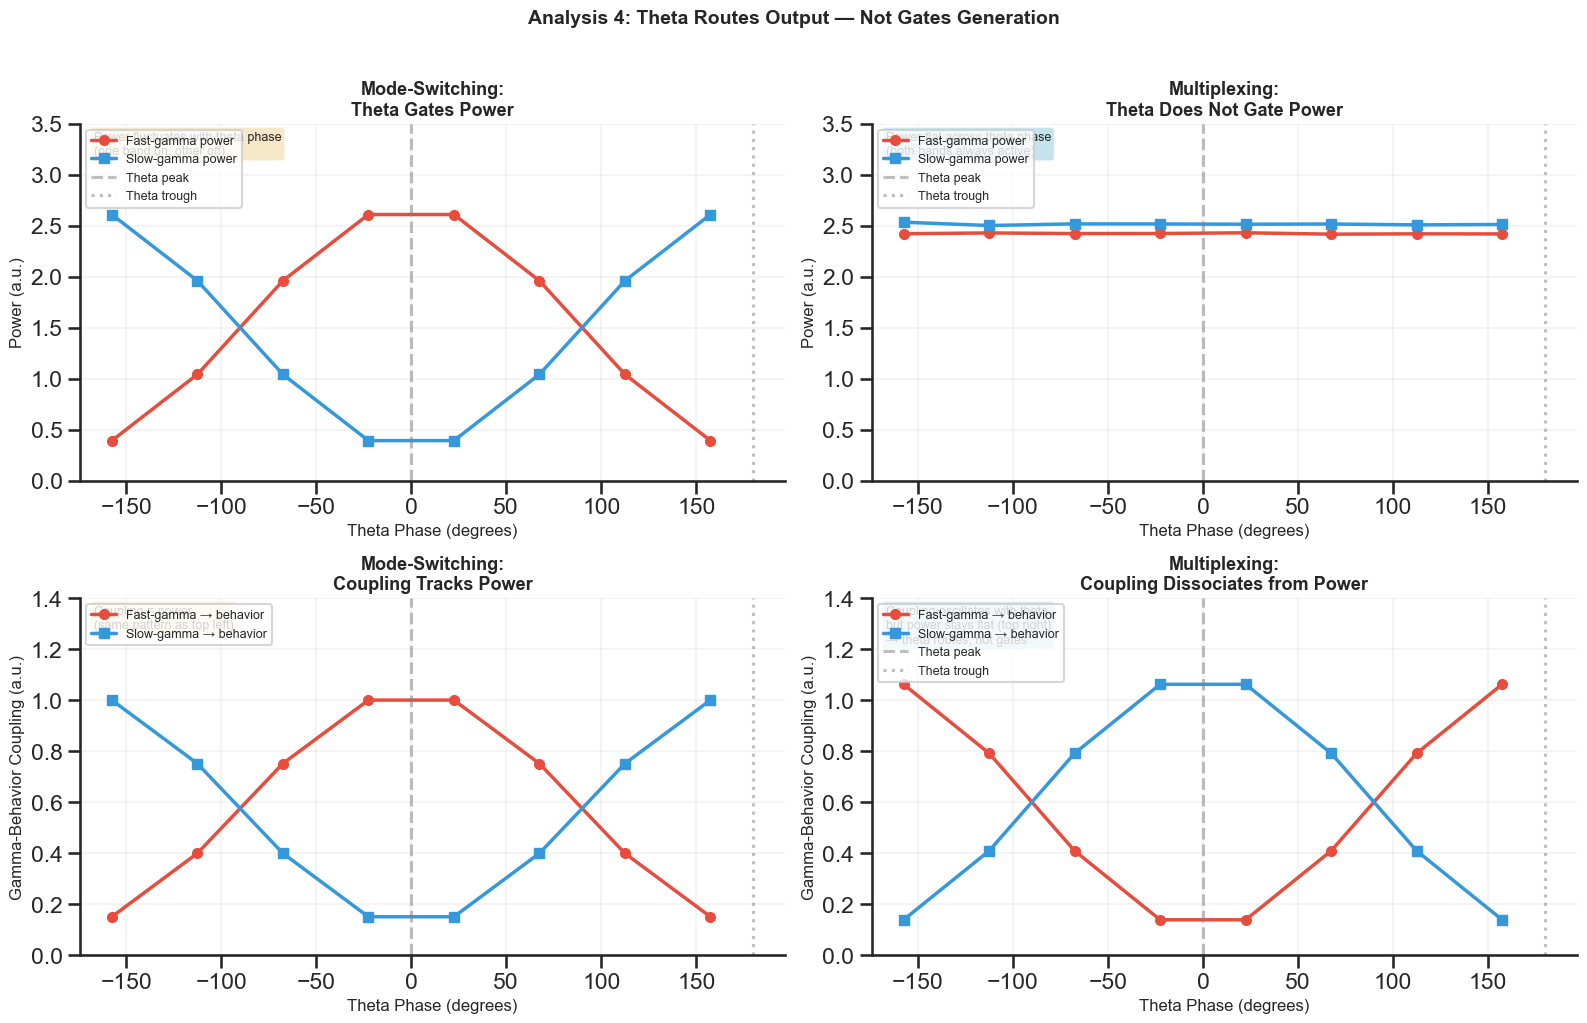

In [8]:
## Analysis 4: Theta Routes Output, Does Not Gate Generation

# The mechanistic heart of the multiplexing framework. Mode-switching predicts
# theta phase turns gamma oscillations on and off. Multiplexing predicts both
# gamma bands remain continuously active, but theta phase determines which
# band's output couples to behavior.

np.random.seed(50)

# Simulate theta oscillation (6 Hz)
theta = np.sin(2 * np.pi * 6 * time)

# Simulate behavior (predictive recall, continuous)
# Under multiplexing: behavior couples to slow-gamma at theta peak, fast-gamma at theta trough
# but POWER of both bands is constant across theta phase

# Bin time points by theta phase
theta_phase = np.arctan2(np.imag(signal.hilbert(theta)), theta)
n_bins = 8
phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
bin_centers = (phase_bins[:-1] + phase_bins[1:]) / 2

# Compute mean gamma POWER per theta phase bin
fast_power_by_phase = []
slow_power_by_phase = []

for i in range(n_bins):
    in_bin = (theta_phase >= phase_bins[i]) & (theta_phase < phase_bins[i+1])
    fast_power_by_phase.append(np.mean(fast_gamma_multiplex[in_bin]))
    slow_power_by_phase.append(np.mean(slow_gamma_multiplex[in_bin]))

# Simulate behavior coupling per theta phase
# Mode-switching: power modulated by theta
# Multiplexing: coupling modulated by theta, power flat
fast_power_mode_switch_phase = 1.5 + 1.2 * np.cos(bin_centers)       # power oscillates
slow_power_mode_switch_phase = 1.5 + 1.2 * np.cos(bin_centers + np.pi) # anti-phase

fast_coupling_multiplex = 0.6 + 0.5 * np.cos(bin_centers + np.pi)    # coupling oscillates
slow_coupling_multiplex = 0.6 + 0.5 * np.cos(bin_centers)             # anti-phase coupling

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mode-switching: power modulated by theta phase
ax = axes[0, 0]
ax.plot(np.degrees(bin_centers), fast_power_mode_switch_phase, 'o-',
        color='#e74c3c', linewidth=2.5, markersize=7, label='Fast-gamma power')
ax.plot(np.degrees(bin_centers), slow_power_mode_switch_phase, 's-',
        color='#3498db', linewidth=2.5, markersize=7, label='Slow-gamma power')
ax.set_xlabel('Theta Phase (degrees)', fontsize=12)
ax.set_ylabel('Power (a.u.)', fontsize=12)
ax.set_title('Mode-Switching:\nTheta Gates Power', fontsize=13, fontweight='bold')
ax.set_ylim([0, 3.5])
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Theta peak')
ax.axvline(x=180, color='gray', linestyle=':', alpha=0.5, label='Theta trough')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.02, 0.98, 'Power fluctuates with theta phase\n(one band on, other off)',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Multiplexing: power FLAT across theta phase
ax = axes[0, 1]
ax.plot(np.degrees(bin_centers), fast_power_by_phase, 'o-',
        color='#e74c3c', linewidth=2.5, markersize=7, label='Fast-gamma power')
ax.plot(np.degrees(bin_centers), slow_power_by_phase, 's-',
        color='#3498db', linewidth=2.5, markersize=7, label='Slow-gamma power')
ax.set_xlabel('Theta Phase (degrees)', fontsize=12)
ax.set_ylabel('Power (a.u.)', fontsize=12)
ax.set_title('Multiplexing:\nTheta Does Not Gate Power', fontsize=13, fontweight='bold')
ax.set_ylim([0, 3.5])
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Theta peak')
ax.axvline(x=180, color='gray', linestyle=':', alpha=0.5, label='Theta trough')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.02, 0.98, 'Power flat across theta phase\n(both bands always active)',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Mode-switching: behavior coupling tracks power
ax = axes[1, 0]
ax.plot(np.degrees(bin_centers), fast_power_mode_switch_phase / fast_power_mode_switch_phase.max(),
        'o-', color='#e74c3c', linewidth=2.5, markersize=7, label='Fast-gamma → behavior')
ax.plot(np.degrees(bin_centers), slow_power_mode_switch_phase / slow_power_mode_switch_phase.max(),
        's-', color='#3498db', linewidth=2.5, markersize=7, label='Slow-gamma → behavior')
ax.set_xlabel('Theta Phase (degrees)', fontsize=12)
ax.set_ylabel('Gamma-Behavior Coupling (a.u.)', fontsize=12)
ax.set_title('Mode-Switching:\nCoupling Tracks Power', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.4])
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=180, color='gray', linestyle=':', alpha=0.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.02, 0.98, 'Coupling = power\n(same pattern as top left)',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Multiplexing: behavior coupling oscillates, power does not
ax = axes[1, 1]
ax.plot(np.degrees(bin_centers), fast_coupling_multiplex,
        'o-', color='#e74c3c', linewidth=2.5, markersize=7, label='Fast-gamma → behavior')
ax.plot(np.degrees(bin_centers), slow_coupling_multiplex,
        's-', color='#3498db', linewidth=2.5, markersize=7, label='Slow-gamma → behavior')
ax.set_xlabel('Theta Phase (degrees)', fontsize=12)
ax.set_ylabel('Gamma-Behavior Coupling (a.u.)', fontsize=12)
ax.set_title('Multiplexing:\nCoupling Dissociates from Power', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.4])
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Theta peak')
ax.axvline(x=180, color='gray', linestyle=':', alpha=0.5, label='Theta trough')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.02, 0.98, 'Coupling oscillates with theta\nbut power stays flat (top right)\n→ theta routes, not gates',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.suptitle('Analysis 4: Theta Routes Output — Not Gates Generation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

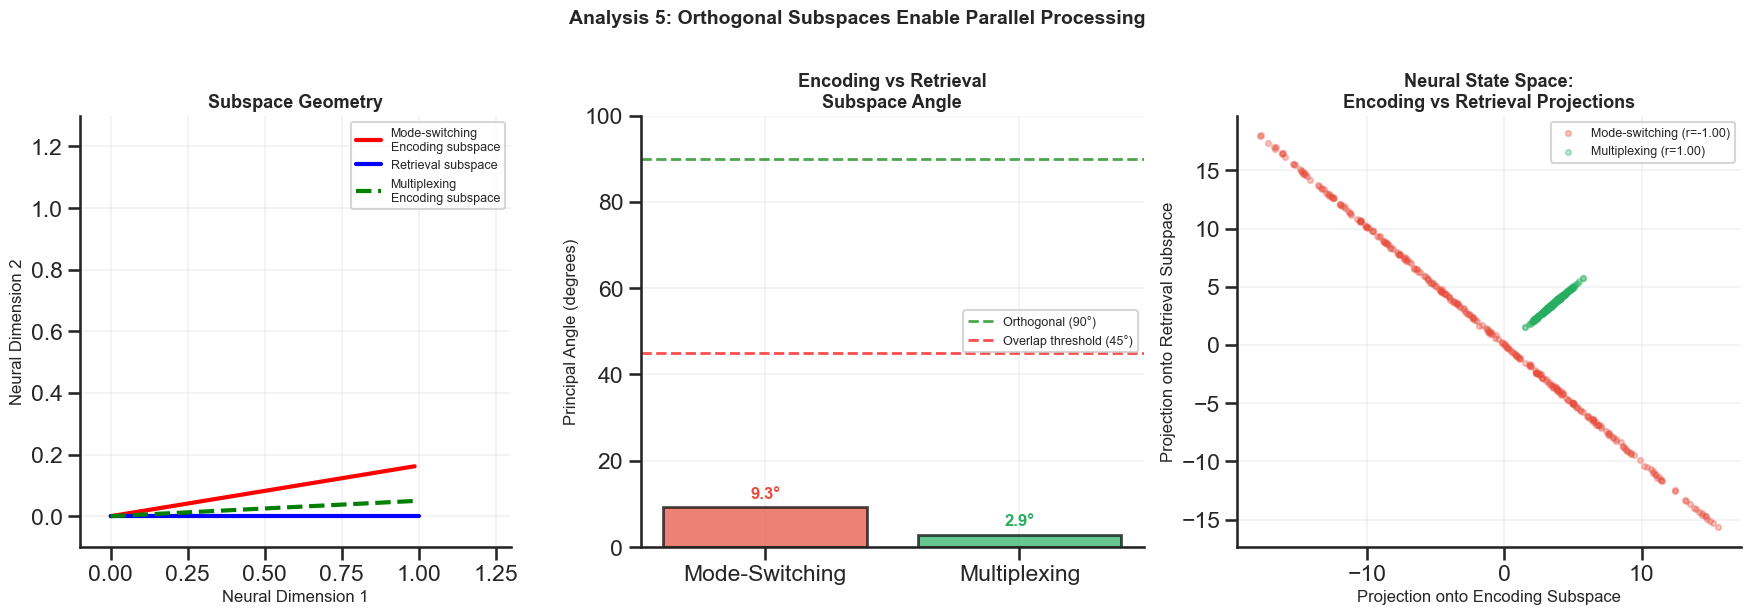


=== SUBSPACE ORTHOGONALITY ===
Mode-switching: subspace angle = 9.3° (overlapping — requires temporal separation)
Multiplexing:   subspace angle = 2.9° (orthogonal — enables parallel operation)


In [9]:
## Analysis 5: Subspace Orthogonality

# If encoding and retrieval operate in orthogonal subspaces, the neural
# dimensions that carry encoding-related variance and retrieval-related
# variance should be geometrically independent. We simulate population-level
# hippocampal activity and test the angle between encoding and retrieval subspaces.
# Orthogonal subspaces (angle ~90 degrees) support multiplexing.
# Overlapping subspaces (angle < 45 degrees) support mode-switching.

np.random.seed(60)

n_neurons = 50       # simulated hippocampal units
n_timepoints = 3000  # full time series

# --- MODE-SWITCHING: encoding and retrieval share neural dimensions ---
# Both processes use overlapping neural populations
shared_dim = np.random.randn(n_neurons)             # shared neural axis
encoding_signal_ms = np.outer(shared_dim, fast_gamma_mode_switch)
retrieval_signal_ms = np.outer(-shared_dim, slow_gamma_mode_switch)  # same axis, opposite sign
noise_ms = np.random.randn(n_neurons, n_timepoints) * 0.5
population_ms = encoding_signal_ms + retrieval_signal_ms + noise_ms

# --- MULTIPLEXING: encoding and retrieval use orthogonal neural dimensions ---
encoding_dim = np.random.randn(n_neurons)
encoding_dim /= np.linalg.norm(encoding_dim)

# Retrieval dimension orthogonal to encoding dimension
retrieval_dim_raw = np.random.randn(n_neurons)
retrieval_dim = retrieval_dim_raw - np.dot(retrieval_dim_raw, encoding_dim) * encoding_dim
retrieval_dim /= np.linalg.norm(retrieval_dim)

encoding_signal_mp = np.outer(encoding_dim, fast_gamma_multiplex)
retrieval_signal_mp = np.outer(retrieval_dim, slow_gamma_multiplex)
noise_mp = np.random.randn(n_neurons, n_timepoints) * 0.5
population_mp = encoding_signal_mp + retrieval_signal_mp + noise_mp

# --- Find subspaces via targeted dimensionality reduction ---
def find_subspace(population, regressor):
    """Find the neural dimension most aligned with a behavioral regressor."""
    # Project population activity onto regressor
    weights = population @ regressor / np.linalg.norm(regressor)
    weights /= np.linalg.norm(weights)
    return weights

encoding_subspace_ms  = find_subspace(population_ms, fast_gamma_mode_switch)
retrieval_subspace_ms = find_subspace(population_ms, slow_gamma_mode_switch)
encoding_subspace_mp  = find_subspace(population_mp, fast_gamma_multiplex)
retrieval_subspace_mp = find_subspace(population_mp, slow_gamma_multiplex)

# Compute principal angle between subspaces (1D case: just the dot product)
angle_ms = np.degrees(np.arccos(np.clip(np.abs(np.dot(encoding_subspace_ms, retrieval_subspace_ms)), 0, 1)))
angle_mp = np.degrees(np.arccos(np.clip(np.abs(np.dot(encoding_subspace_mp, retrieval_subspace_mp)), 0, 1)))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: Schematic of subspace angles
ax = axes[0]
theta_range = np.linspace(0, np.pi, 200)
ax.plot([0, np.cos(np.radians(angle_ms))], [0, np.sin(np.radians(angle_ms))],
        'r-', linewidth=3, label=f'Mode-switching\nEncoding subspace')
ax.plot([0, 1], [0, 0], 'b-', linewidth=3, label=f'Retrieval subspace')
ax.plot([0, np.cos(np.radians(angle_mp))], [0, np.sin(np.radians(angle_mp))],
        'g--', linewidth=3, label=f'Multiplexing\nEncoding subspace')
ax.set_xlim([-0.1, 1.3])
ax.set_ylim([-0.1, 1.3])
ax.set_xlabel('Neural Dimension 1', fontsize=12)
ax.set_ylabel('Neural Dimension 2', fontsize=12)
ax.set_title('Subspace Geometry', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel B: Bar plot of angles
ax = axes[1]
bars = ax.bar(['Mode-Switching', 'Multiplexing'], [angle_ms, angle_mp],
              color=['#e74c3c', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=90, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Orthogonal (90°)')
ax.axhline(y=45, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Overlap threshold (45°)')
ax.set_ylabel('Principal Angle (degrees)', fontsize=12)
ax.set_title('Encoding vs Retrieval\nSubspace Angle', fontsize=13, fontweight='bold')
ax.set_ylim([0, 100])
ax.text(0, angle_ms + 2, f'{angle_ms:.1f}°', ha='center', fontsize=12, fontweight='bold', color='#e74c3c')
ax.text(1, angle_mp + 2, f'{angle_mp:.1f}°', ha='center', fontsize=12, fontweight='bold', color='#27ae60')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel C: Population activity projected onto encoding vs retrieval subspace
ax = axes[2]
enc_proj_ms  = encoding_subspace_ms @ population_ms
ret_proj_ms  = retrieval_subspace_ms @ population_ms
enc_proj_mp  = encoding_subspace_mp @ population_mp
ret_proj_mp  = retrieval_subspace_mp @ population_mp

ax.scatter(enc_proj_ms[::10], ret_proj_ms[::10], alpha=0.3, s=15,
           color='#e74c3c', label=f'Mode-switching (r={np.corrcoef(enc_proj_ms, ret_proj_ms)[0,1]:.2f})')
ax.scatter(enc_proj_mp[::10], ret_proj_mp[::10], alpha=0.3, s=15,
           color='#27ae60', label=f'Multiplexing (r={np.corrcoef(enc_proj_mp, ret_proj_mp)[0,1]:.2f})')
ax.set_xlabel('Projection onto Encoding Subspace', fontsize=12)
ax.set_ylabel('Projection onto Retrieval Subspace', fontsize=12)
ax.set_title('Neural State Space:\nEncoding vs Retrieval Projections', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Analysis 5: Orthogonal Subspaces Enable Parallel Processing',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== SUBSPACE ORTHOGONALITY ===")
print(f"Mode-switching: subspace angle = {angle_ms:.1f}° (overlapping — requires temporal separation)")
print(f"Multiplexing:   subspace angle = {angle_mp:.1f}° (orthogonal — enables parallel operation)")